# Metodología y Diseño de Experimentos

En aplicaciones agrícolas modernas, la disponibilidad de datos no implica necesariamente que todas las variables deban medirse. Cada medición tiene un costo asociado, económico, logístico y temporal por lo que surge una pregunta fundamental:

    ¿Qué variables realmente aportan valor predictivo y justifican su costo de adquisición? 

En este notebook abordamos esta pregunta desde una perspectiva de Machine Learning aplicado al Diseño de Experimentos (DoE), utilizando un conjunto de datos agronómicos que incluye variables del suelo (N, P, K, pH), variables climáticas (temperatura, humedad, precipitación) y el tipo de cultivo.

El objetivo no es únicamente entrenar modelos predictivos, sino evaluar formalmente, mediante hipótesis estadísticas, si ciertas mediciones costosas pueden omitirse sin degradar significativamente el desempeño del modelo.

## Enfoque del análisis

Se estudiarán dos tipos de problemas supervisados:

* Clasificación: Predicción del tipo de cultivo más adecuado.

En ambos casos se formularán hipótesis nulas relacionadas con el valor informativo de variables costosas frente a variables de bajo costo. Esto permitirá responder preguntas como:

* ¿Es necesario realizar análisis de suelo para recomendar un cultivo?
* ¿El pH aporta información adicional cuando ya se dispone de datos climáticos?
  
Para ello planteamos hipótesis asociadas para obtener la respuesta a estas preguntas.

## Hipótesis para Clasificación (tipo de cultivo)
### C1) No predictividad de NPK para recomendar cultivo

Motivación:
Si NPK no aporta señal predictiva significativa para clasificar el cultivo, podríamos evitar análisis de suelo costosos en aplicaciones de recomendación agrícola.

$H_0$: Las variables N, P y K no proporcionan capacidad predictiva superior al azar para clasificar el tipo de cultivo.

$H_1$: NPK aporta señal predictiva significativa.

### C2) El pH no aporta valor adicional si ya conocemos el clima

Motivación:
Si la clasificación del cultivo puede realizarse adecuadamente con variables climáticas de bajo costo, el pH podría ser redundante.

$H_0$: Añadir pH a un modelo basado en temperatura, humedad y precipitación no mejora significativamente la capacidad de clasificación.

$H_1$: El pH aporta mejora predictiva significativa.

### Carga de datos para el análisis

Para efectos de este taller realizaremos una clasificación sobre el siguiente [Dataset](https://www.kaggle.com/datasets/ryandinh/agricultural-production-optimization) y una regresión sobre una variable sintética generada.

In [1]:
# Exploración de datos y estadísticas descriptivas
import pandas as pd 
from utils.data_generation import generate_data
df = generate_data()
df.describe()

Path to dataset files: /home/jovillalobos/.cache/kagglehub/datasets/ryandinh/agricultural-production-optimization/versions/1


,N,P,K,temperature,humidity,ph,rainfall,yield
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,1.018450
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,2.330161
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,0.000000
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,0.000000
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,0.000000
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,0.777971
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,22.633051


In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor

In [3]:
FEATURES_ALL = ["N","P","K","temperature","humidity","ph","rainfall"]
FEATURES_NO_NPK = ["temperature","humidity","ph","rainfall"]

FEATURES_CLIMATE = ["temperature","humidity","rainfall"]
FEATURES_CLIMATE_PH = ["temperature","humidity","rainfall","ph"]


X_all = df[FEATURES_ALL].copy()

# C1
X_nonpk = df[FEATURES_NO_NPK].copy()

# C2
X_climate = df[FEATURES_CLIMATE].copy()
X_climate_ph = df[FEATURES_CLIMATE_PH].copy()

# Variables de salida
y_cls = df["label"].copy()

Utilizaremos 

In [4]:
# Podríamos cambiar esto por Random Forest Classifier

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(criterion="entropy"))
])

## Evaluación del modelo mediante validación cruzada estratificada

Sea un conjunto de datos

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{N}
$$

donde:

- $x_i \in \mathbb{R}^p$ es el vector de características
- $y_i \in \{1,\dots,C\}$ es la etiqueta de clase

---

### Partición mediante validación cruzada

Se utiliza **validación cruzada estratificada** con $K$ folds.

Esto produce una partición del dataset:

$$
\mathcal{D} = \bigcup_{k=1}^{K} \mathcal{D}_k
$$

donde cada fold preserva aproximadamente la distribución de clases:

$$
P(y=c \mid \mathcal{D}_k) \approx P(y=c \mid \mathcal{D})
$$

para cada clase $c$.

---

### Entrenamiento y evaluación por fold

Para cada fold $k$:

1. **Conjunto de entrenamiento**

$$
\mathcal{D}_{train}^{(k)} =
\mathcal{D} \setminus \mathcal{D}_k
$$

2. **Conjunto de test**

$$
\mathcal{D}_{test}^{(k)} =
\mathcal{D}_k
$$

3. Entrenamos el modelo

$$
\hat{f}^{(k)} =
\text{Train}(\mathcal{D}_{train}^{(k)})
$$

4. Generamos predicciones

$$
\hat{y}_i^{(k)} =
\hat{f}^{(k)}(x_i),
\quad (x_i,y_i)\in\mathcal{D}_{test}^{(k)}
$$

---

### Cálculo del F1-score por clase

Para cada clase $c$:

$$
\text{Precision}_c =
\frac{TP_c}{TP_c + FP_c}
$$

$$
\text{Recall}_c =
\frac{TP_c}{TP_c + FN_c}
$$

El **F1-score por clase** es

$$
F1_c =
\frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}
{\text{Precision}_c + \text{Recall}_c}
$$

---

### Macro-F1

El **macro-F1** promedia el F1 de cada clase sin ponderación:

$$
F1_{macro}^{(k)} =
\frac{1}{C}
\sum_{c=1}^{C} F1_c
$$

---

### Resultado final

El procedimiento produce un vector de scores:

$$
\mathbf{s} =
\left(
F1_{macro}^{(1)},
F1_{macro}^{(2)},
\dots,
F1_{macro}^{(K)}
\right)
$$

que corresponde al desempeño del modelo en cada fold de la validación cruzada.

Este vector permite estimar el desempeño esperado del modelo y analizar su variabilidad entre particiones del dataset.

In [5]:
def cv_score_classification(X, y, model, n_splits=10, seed=0):
    """
    Evalúa el desempeño de un modelo de clasificación utilizando
    validación cruzada estratificada.

    Parámetros
    ----------
    X : DataFrame
        Matriz de características (features).
    y : Series o array
        Etiquetas de clase.
    model : estimator de sklearn
        Modelo de clasificación que se desea evaluar.
    n_splits : int
        Número de folds para la validación cruzada.
    seed : int
        Semilla para reproducibilidad al mezclar los datos.

    Retorna
    -------
    np.array
        Vector con el macro-F1 obtenido en cada fold.
    """

    # StratifiedKFold mantiene la proporción de clases en cada fold
    # lo cual es importante en problemas multiclase
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    scores = []

    # Iteramos sobre los folds
    for tr, te in skf.split(X, y):

        # Entrenamos el modelo con los índices de entrenamiento
        model.fit(X.iloc[tr], y.iloc[tr])

        # Predecimos en el conjunto de test del fold
        pred = model.predict(X.iloc[te])

        # Calculamos macro-F1
        # macro promedia el F1 de cada clase sin ponderación
        scores.append(f1_score(y.iloc[te], pred, average="macro"))

    # Retornamos los scores como arreglo numpy
    return np.array(scores)

## Intervalo de confianza mediante bootstrap pareado

Sea un conjunto de diferencias de desempeño entre dos modelos

$$
d = \{d_1, d_2, \dots, d_n\}
$$

donde cada diferencia corresponde al desempeño en un fold de validación cruzada:

$$
d_k = S_A^{(k)} - S_B^{(k)}
$$

con $S_A^{(k)}$ y $S_B^{(k)}$ representando el score del modelo $A$ y $B$ respectivamente en el fold $k$.

El objetivo es estimar el parámetro poblacional

$$
\theta = \mathbb{E}[d]
$$

o alternativamente

$$
\theta = \text{median}(d)
$$

dependiendo del estadístico elegido.

---

## Procedimiento bootstrap

El método bootstrap consiste en generar $B$ muestras remuestreadas con reemplazo del vector original $d$.

Para cada iteración $b = 1, \dots, B$:

1. Generamos una muestra bootstrap

$$
d^{*(b)} = \{ d_{i_1}, d_{i_2}, \dots, d_{i_n} \}
$$

donde los índices

$$
i_j \sim \text{Uniform}\{1, \dots, n\}
$$

son seleccionados **con reemplazo**.

2. Calculamos el estadístico de interés

Si usamos la media:

$$
\theta^{*(b)} = \frac{1}{n} \sum_{j=1}^{n} d_{i_j}
$$

Si usamos la mediana:

$$
\theta^{*(b)} = \text{median}(d^{*(b)})
$$

Después de $B$ iteraciones obtenemos la distribución bootstrap

$$
\Theta^* =
\{\theta^{*(1)}, \theta^{*(2)}, \dots, \theta^{*(B)}\}
$$

---

## Intervalo de confianza percentil

El intervalo de confianza bootstrap del nivel $1-\alpha$ se calcula utilizando cuantiles de la distribución bootstrap:

$$
CI_{1-\alpha} =
\left[
Q_{\alpha/2}(\Theta^*),
\;
Q_{1-\alpha/2}(\Theta^*)
\right]
$$

donde $Q_p(\cdot)$ representa el cuantíl $p$.

Para un intervalo de confianza del 95%:

$$
\alpha = 0.05
$$

$$
CI_{95\%} =
\left[
Q_{0.025}(\Theta^*),
\;
Q_{0.975}(\Theta^*)
\right]
$$

---

## Estimación puntual

La estimación central del parámetro se calcula a partir de los datos originales:

Si usamos la media:

$$
\hat{\theta} = \frac{1}{n}\sum_{k=1}^{n} d_k
$$

Si usamos la mediana:

$$
\hat{\theta} = \text{median}(d)
$$

---

In [6]:
def paired_bootstrap_ci(diffs, B=50, seed=0, ci=0.95, stat="mean"):
    """
    Calcula un intervalo de confianza mediante bootstrap pareado
    para la diferencia de desempeño entre dos modelos.

    Parámetros
    ----------
    diffs : array-like
        Diferencias de desempeño entre modelos en cada fold.
        Ejemplo: F1(modelo_A) - F1(modelo_B)
    B : int
        Número de remuestreos bootstrap.
    seed : int
        Semilla aleatoria para reproducibilidad.
    ci : float
        Nivel de confianza (por ejemplo 0.95 para 95%).
    stat : str
        Estadístico a estimar: 'mean' o 'median'.

    Retorna
    -------
    center : float
        Estimación central del estadístico (media o mediana).
    (lo, hi) : tuple
        Intervalo de confianza bootstrap.
    boots : array
        Distribución bootstrap generada.
    """

    rng = np.random.default_rng(seed)

    # Convertimos a numpy array para facilitar operaciones
    diffs = np.asarray(diffs)

    boots = []
    n = len(diffs)

    # Generamos B muestras bootstrap
    for _ in range(B):

        # Remuestreo con reemplazo de los diffs
        # simula repetir el experimento con nuevos folds
        samp = diffs[rng.integers(0, n, size=n)]

        # Calculamos el estadístico de interés
        if stat == "mean":
            boots.append(np.mean(samp))
        else:
            boots.append(np.median(samp))

    # Convertimos la colección de estadísticos bootstrap a array
    boots = np.array(boots)

    # Cálculo del intervalo de confianza percentil
    alpha = (1 - ci) / 2
    lo = np.quantile(boots, alpha)
    hi = np.quantile(boots, 1 - alpha)

    # Estimación central usando los datos originales
    center = np.mean(diffs) if stat == "mean" else np.median(diffs)

    return center, (lo, hi), boots

## Interpretación

El intervalo bootstrap aproxima la distribución muestral del estadístico $\theta$.

En el contexto de comparación de modelos:

- Si

$$
0 \notin CI_{95\%}
$$

existe evidencia de una diferencia sistemática entre modelos.

- Si

$$
0 \in CI_{95\%}
$$

no hay evidencia suficiente para afirmar que uno de los modelos tenga mejor desempeño esperado.

In [7]:
# Metodología frecuentista

s_nonpk = cv_score_classification(X_nonpk, y_cls, clf, seed=0)
s_all = cv_score_classification(X_all, y_cls, clf, seed=0)

diffs_npk = s_all - s_nonpk
center, (lo, hi), _ = paired_bootstrap_ci(diffs_npk, B=100, seed=0, ci=0.95)

print("C1 incremental - ΔmacroF1:", center)
print("95% CI:", (lo, hi))

# regla (una cola)
decision = "Rechazar H0" if lo > 0 else "No rechazar H0"
print("Decisión:", decision)

C1 incremental - ΔmacroF1: 0.03077361071579071
95% CI: (0.02293421020515939, 0.037663193894284665)
Decisión: Rechazar H0


In [8]:
# Metodología frecuentista

s_climate = cv_score_classification(X_climate, y_cls, clf, seed=0)
s_climate_ph = cv_score_classification(X_climate_ph, y_cls, clf, seed=0)

diffs_climate = s_climate_ph - s_climate
center, (lo, hi), _ = paired_bootstrap_ci(diffs_climate, B=100, seed=0, ci=0.95)

print("C1 incremental - ΔmacroF1:", center)
print("95% CI:", (lo, hi))

# regla (una cola)
decision = "Rechazar H0" if lo > 0 else "No rechazar H0"
print("Decisión:", decision)

C1 incremental - ΔmacroF1: 0.03991903750361081
95% CI: (0.033362407988549767, 0.0485047501326652)
Decisión: Rechazar H0


## Comparación bayesiana de modelos mediante diferencias pareadas

Sea un conjunto de diferencias de desempeño entre dos modelos evaluados mediante validación cruzada:

$$
d = \{d_1, d_2, \dots, d_n\}
$$

donde cada diferencia se define como

$$
d_k = S_A^{(k)} - S_B^{(k)}
$$

con $S_A^{(k)}$ y $S_B^{(k)}$ representando el desempeño de los modelos $A$ y $B$ respectivamente en el fold $k$.

El objetivo es inferir la **mejora promedio verdadera**

$$
\mu = \mathbb{E}[d]
$$

---

# Modelo probabilístico

Para modelar las diferencias se utiliza una distribución **Student-t**, que es robusta frente a outliers:

$$
d_k \sim \text{StudentT}(\nu, \mu, \sigma)
$$

donde:

- $\mu$ es la diferencia promedio verdadera entre los modelos
- $\sigma$ representa la variabilidad entre folds
- $\nu$ controla el peso de las colas (robustez)

---

# Priors

Se especifican distribuciones a priori débiles para los parámetros:

### Media

$$
\mu \sim \mathcal{N}(0, \tau^2)
$$

donde $\tau$ es una escala proporcional a la desviación observada de los datos.

---

### Desviación estándar

$$
\sigma \sim \text{HalfNormal}(\tau)
$$

lo cual garantiza

$$
\sigma > 0
$$

---

### Grados de libertad

$$
\nu \sim \text{Exponential}(\lambda) + 2
$$

lo que asegura

$$
\nu > 2
$$

y por lo tanto una varianza finita para la distribución Student-t.

---

# Inferencia bayesiana

Dado el conjunto de datos $d$, la inferencia se basa en la distribución posterior

$$
p(\mu, \sigma, \nu \mid d)
\propto
p(d \mid \mu, \sigma, \nu)
\,
p(\mu)
\,
p(\sigma)
\,
p(\nu)
$$

Esta distribución posterior se aproxima mediante **Markov Chain Monte Carlo (MCMC)**.

---

# Probabilidades posteriores de interés

Una vez obtenidas muestras posteriores de $\mu$, se calculan probabilidades relevantes.

### Probabilidad de mejora significativa

Sea $\delta$ un umbral mínimo de mejora práctica.

$$
P(\mu > \delta \mid d)
$$

se estima como

$$
\frac{1}{M}
\sum_{i=1}^{M}
\mathbb{I}(\mu_i > \delta)
$$

donde $\{\mu_i\}_{i=1}^{M}$ son muestras de la distribución posterior.

---

### Región de equivalencia práctica (ROPE)

Definimos una región de equivalencia práctica

$$
\text{ROPE} = [-\delta, \delta]
$$

La probabilidad de equivalencia se calcula como

$$
P(|\mu| < \delta \mid d)
=
\frac{1}{M}
\sum_{i=1}^{M}
\mathbb{I}(-\delta \le \mu_i \le \delta)
$$

---

# Intervalo creíble

También se calcula el intervalo creíble del 95%:

$$
CI_{95\%} =
\left[
Q_{0.025}(\mu),
\;
Q_{0.975}(\mu)
\right]
$$

donde $Q_p$ representa el cuantíl $p$ de la distribución posterior.

---

# Interpretación

Las decisiones se basan en probabilidades posteriores:

- Si

$$
P(\mu > \delta \mid d) > 0.95
$$

existe fuerte evidencia de mejora.

- Si

$$
P(|\mu| < \delta \mid d) > 0.95
$$

los modelos son prácticamente equivalentes.

- En otros casos, la evidencia es **inconclusa**.

In [9]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

def bayes_compare_diffs(
    diffs,
    delta=0.0,
    rope=None,
    draws=2000,
    tune=1000,
    chains=4,
    seed=0,
):
    """
    Bayes para comparar modelos usando diffs pareados.
    diffs: array de d_k = score_A - score_B (por fold/split)
    delta: umbral de mejora relevante (una cola)
    rope: tupla (a,b) para equivalencia práctica; si None usa (-delta, delta)
    """
    diffs = np.asarray(diffs, dtype=float)
    if rope is None:
        rope = (-abs(delta), abs(delta))

    # Escala razonable para priors, basada en magnitud observada
    s0 = np.std(diffs, ddof=1) if len(diffs) > 1 else 1.0
    s0 = max(s0, 1e-3)

    with pm.Model() as model:
        # Prior: mejora media cerca de 0 con escala moderada
        mu = pm.Normal("mu", mu=0.0, sigma=2.0 * s0)

        # Prior: dispersión positiva
        sigma = pm.HalfNormal("sigma", sigma=2.0 * s0)

        # Prior para colas: favorece robustez pero permite casi-normalidad
        nu = pm.Exponential("nu", lam=1/10) + 2  # asegura nu > 2 (varianza finita)

        # Likelihood robusta
        pm.StudentT("obs", nu=nu, mu=mu, sigma=sigma, observed=diffs)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            random_seed=seed,
            target_accept=0.9,
            progressbar=True,
        )

    mu_s = idata.posterior["mu"].values.ravel()

    # Probabilidades posteriores para decisiones
    p_improve = float((mu_s > delta).mean())                # P(mu > delta)
    p_equiv   = float(((mu_s >= rope[0]) & (mu_s <= rope[1])).mean())  # P(mu en ROPE)

    # Intervalo creíble 95%
    hdi = az.hdi(mu_s, hdi_prob=0.95)
    hdi = (float(hdi[0]), float(hdi[1]))

    summary = {
        "p_improve": p_improve,
        "p_equiv": p_equiv,
        "hdi95_mu": hdi,
        "rope": rope,
        "delta": delta,
        "idata": idata,   # por si quieres trazas/diagnósticos
    }
    return summary

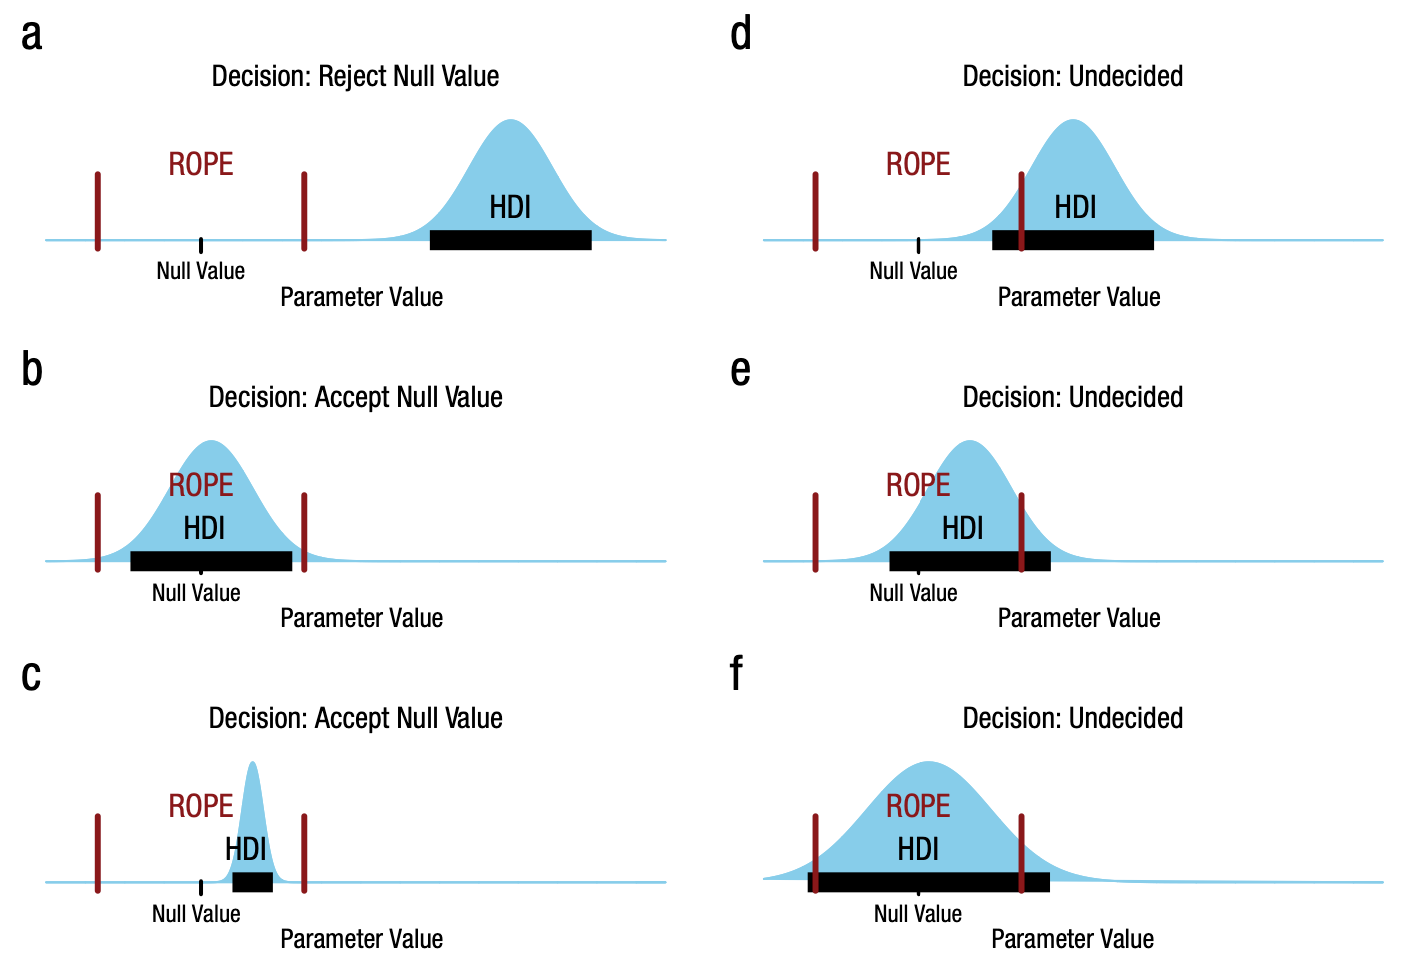

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


P(mu > delta) = 0.0
P(mu en ROPE) = 1.0
HDI95(mu)     = (0.02114292583444465, 0.03854525936819374)
ROPE          = (-0.1, 0.1)


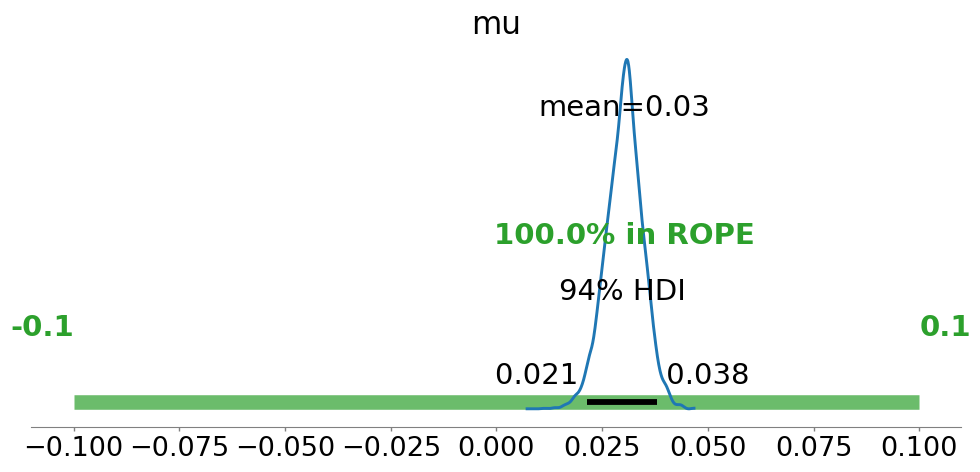

In [15]:
res = bayes_compare_diffs(diffs_npk, delta=0.1, seed=0)

print("P(mu > delta) =", res["p_improve"])
print("P(mu en ROPE) =", res["p_equiv"])
print("HDI95(mu)     =", res["hdi95_mu"])
print("ROPE          =", res["rope"])

mu = res["idata"].posterior["mu"].values.ravel()

delta = res["delta"]
rope_lo, rope_hi = res["rope"]
hdi_lo, hdi_hi = res["hdi95_mu"]

az.plot_posterior(res["idata"], var_names="mu", rope=[-0.1, 0.1], figsize=(12,5))
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, nu]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


P(mu > delta) = 0.0
P(mu en ROPE) = 1.0
HDI95(mu)     = (0.029246390807514747, 0.04572988790472243)
ROPE          = (-0.1, 0.1)


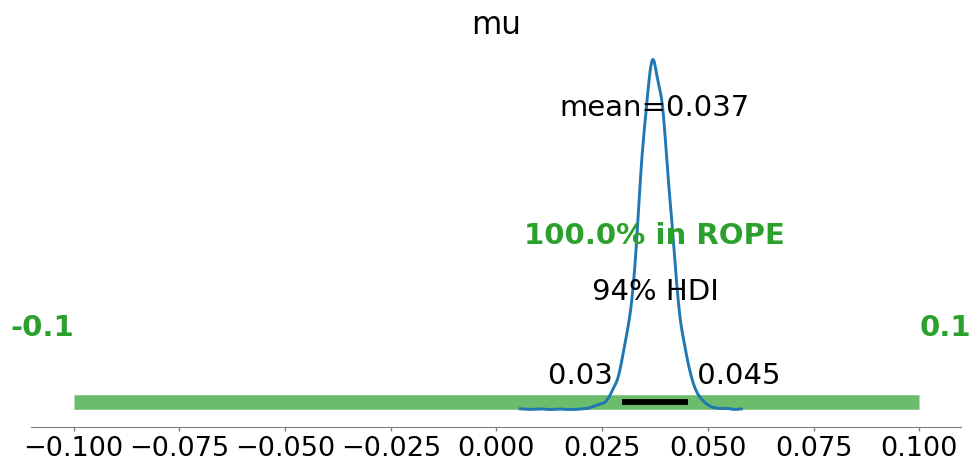

In [14]:
res = bayes_compare_diffs(diffs_climate, delta=0.1, seed=0)

print("P(mu > delta) =", res["p_improve"])
print("P(mu en ROPE) =", res["p_equiv"])
print("HDI95(mu)     =", res["hdi95_mu"])
print("ROPE          =", res["rope"])

mu = res["idata"].posterior["mu"].values.ravel()

delta = res["delta"]
rope_lo, rope_hi = res["rope"]
hdi_lo, hdi_hi = res["hdi95_mu"]

az.plot_posterior(res["idata"], var_names="mu", rope=[-0.1, 0.1], figsize=(12,5))
plt.show()